# RavenStack SaaS — First Look at Churn

**Author:** Namık Akman  
**Dataset:** RavenStack — a simulated B2B SaaS company (500 customers, 5 linked tables).  
**Goal of this notebook:** before any modelling, look at *where* churn is concentrated. Plan tier? Industry? Country? Acquisition channel?

The principle: **insight before model.** A CFO acts on a segment chart, not on an accuracy score.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG_DARK, FG_LIGHT = '#0F1419', '#E6EDF3'

plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_DARK, 'savefig.facecolor': BG_DARK,
    'axes.edgecolor': FG_LIGHT, 'axes.labelcolor': FG_LIGHT,
    'xtick.color': FG_LIGHT, 'ytick.color': FG_LIGHT, 'text.color': FG_LIGHT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv')
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


## 2. The headline number

Before slicing anything: what share of customers churned?

In [2]:
total = len(accounts)
churned = int(accounts['churn_flag'].sum())
churn_rate = churned / total
print(f'Total customers : {total}')
print(f'Churned         : {churned}')
print(f'Churn rate      : {churn_rate:.1%}')

Total customers : 500
Churned         : 110
Churn rate      : 22.0%


**Read:** 22% lifetime churn. That's our anchor — every breakdown below is judged relative to this 22% line.

## 3. A reusable breakdown helper

Same logic four times over: group by one dimension, count customers, count churners, plot. Wrap it once.

In [3]:
def churn_breakdown(df, by):
    g = df.groupby(by).agg(
        customers=('account_id', 'count'),
        churned=('churn_flag', 'sum'),
    )
    g['churn_rate'] = g['churned'] / g['customers']
    return g.sort_values('churn_rate', ascending=False)

def plot_churn(series, title, color=BRAND_BLUE, overall=None):
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(series.index[::-1], (series.values[::-1] * 100), color=color)
    ax.set_xlabel('Churn rate (%)')
    ax.set_title(title, loc='left', pad=15)
    for bar, v in zip(bars, series.values[::-1] * 100):
        ax.text(v + 0.4, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', color=FG_LIGHT, fontsize=9)
    if overall is not None:
        ax.axvline(overall * 100, color=BRAND_ORANGE, linestyle='--', linewidth=1.2, label=f'Overall: {overall:.1%}')
        ax.legend(loc='lower right', facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT)
    ax.set_xlim(0, max(series.values * 100) * 1.18)
    plt.tight_layout(); plt.show()

## 4. Churn by plan tier

In [4]:
plan = churn_breakdown(accounts, 'plan_tier')
plan

,customers,churned,churn_rate
plan_tier,,,
Enterprise,154,34,0.220779
Basic,168,37,0.220238
Pro,178,39,0.219101


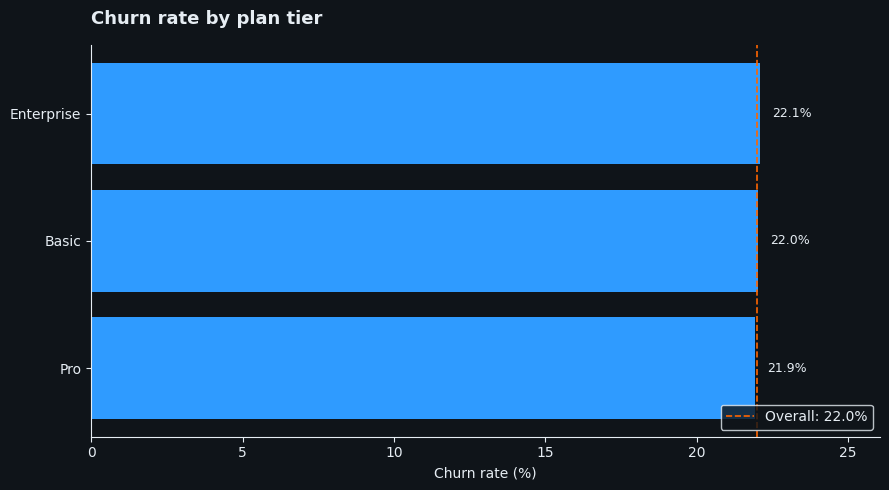

In [5]:
plot_churn(plan['churn_rate'], 'Churn rate by plan tier', color=BRAND_BLUE, overall=churn_rate)

**Read:** All three plan tiers churn at ~22% — *no meaningful difference.* This is itself a finding: **plan tier is not a churn driver.** Don't try to fix churn by re-pricing.  
Where to look instead: *who the customer is* and *how they were acquired.*

## 5. Churn by industry

In [6]:
industry = churn_breakdown(accounts, 'industry')
industry

,customers,churned,churn_rate
industry,,,
DevTools,113,35,0.309735
FinTech,112,25,0.223214
HealthTech,96,21,0.218750
EdTech,79,13,0.164557
Cybersecurity,100,16,0.160000


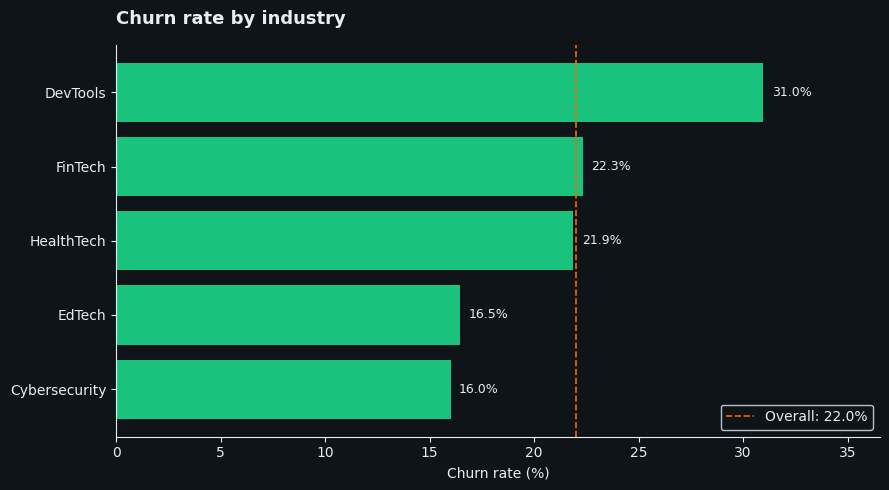

In [7]:
plot_churn(industry['churn_rate'], 'Churn rate by industry', color=BRAND_GREEN, overall=churn_rate)

**Read:** DevTools customers churn at **31%** — nearly 2x Cybersecurity's 16%. The product is clearly stickier for security teams than for developer tooling.  
Implications: rethink positioning or product fit for DevTools; or de-prioritise that segment in acquisition.

## 6. Churn by country

In [8]:
country = churn_breakdown(accounts, 'country')
country

,customers,churned,churn_rate
country,,,
DE,25,8,0.320000
US,291,68,0.233677
FR,22,5,0.227273
IN,49,10,0.204082
UK,58,11,0.189655
CA,23,4,0.173913
AU,32,4,0.125000


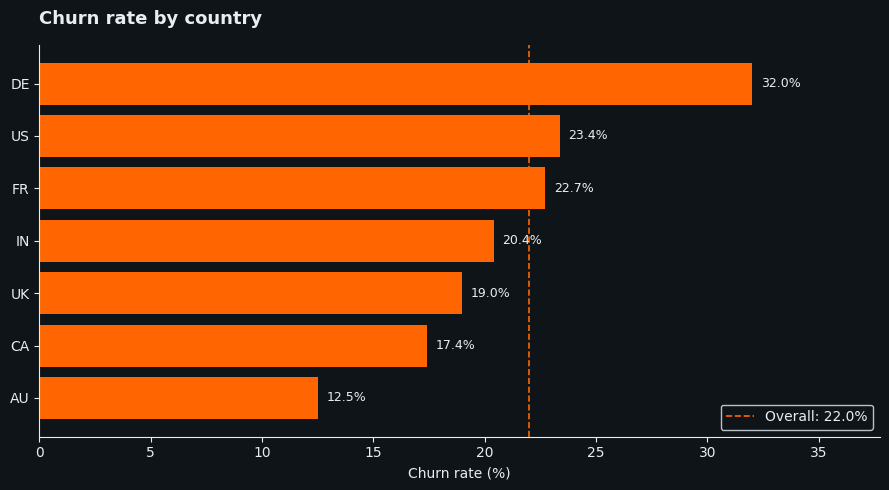

In [9]:
plot_churn(country['churn_rate'], 'Churn rate by country', color=BRAND_ORANGE, overall=churn_rate)

**Read:** Germany shows 32% churn but only 25 customers — sample too small to draw conclusions. The US (291 customers, the bulk of the base) sits at 23.4%, slightly above average. Australia (32 customers, 12.5%) is genuinely the stickiest market.  
**Caveat to keep in mind for the write-up:** flag the small-sample countries explicitly. Don't over-interpret DE/FR/CA.

## 7. Churn by acquisition channel

In [10]:
ref = churn_breakdown(accounts, 'referral_source')
ref

,customers,churned,churn_rate
referral_source,,,
event,96,29,0.302083
other,103,25,0.242718
ads,98,23,0.234694
organic,114,20,0.175439
partner,89,13,0.146067


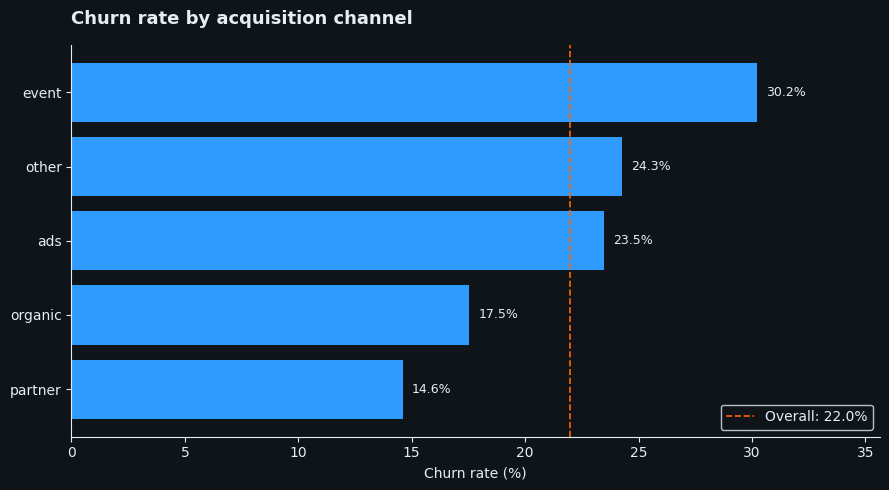

In [11]:
plot_churn(ref['churn_rate'], 'Churn rate by acquisition channel', color=BRAND_BLUE, overall=churn_rate)

**Read — and this is the headline finding so far:**  
Customers acquired through **partners churn at 14.6%**; customers acquired at **events churn at 30.2%**. That's a 2x difference driven entirely by *how the customer entered*.  

Commercial implication: a dollar spent on partner channel is worth roughly twice a dollar spent on event marketing, in retention terms. Sales/marketing mix is a churn lever — not just a CAC lever.

---

## What we've learned in this first pass

1. **22% lifetime churn** is the baseline.
2. **Plan tier doesn't matter** — pricing isn't the lever.
3. **Industry matters a lot** — DevTools ≈ 2× Cybersecurity. Product fit varies by segment.
4. **Acquisition channel matters most** — partner-sourced customers are half as likely to churn as event-sourced ones.
5. Country shows a signal but most cells are too small to act on alone.

## Where to go next

- **Cohort retention curves** — does churn happen early (onboarding problem) or late (value-realisation problem)?
- **Behavioural signal from feature_usage** — do retained customers use a specific 'magic moment' feature?
- **Support tickets vs churn** — does support load predict churn?
- **Reasons** — what do churners *say* in churn_events.feedback_text?
- **A simple predictive model** — once we have the story, build a model to confirm it and quantify lift from interventions.